# Network Intrusion Detection System using Anomaly Detection (CICIDS2017)
### Two-Phase: Autoencoder Anomaly Detection → Random Forest Attack Classification
---
**Sections**
1. Setup & Configuration
2. Data Loading & Preprocessing
3. Phase 1 — Autoencoder Training
4. Phase 2 — Random Forest Training
5. Evaluation on Held-Out Test Set
6. Real-Time Stream Detection & Concept Drift

## Setup & Configuration

In [1]:
!pip install river mlflow pyyaml --quiet
print('Libraries ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 13.6 MB/s eta 0:00:00
Libraries ready


In [2]:
# ---config.yaml ---
import yaml, os

config = {
    'paths': {
        'input':     '/kaggle/input/datasets/teesush/final-data/',
        'artifacts': '/kaggle/working/',
        'log_file':  '/kaggle/working/ids_run.log'
    },
    'data': {
        'original':   'clean_data.csv',             # imbalanced -test set only
        'balanced':   'final_balanced_dataset.csv', # original + CTGAN -training only
        'test_size':  0.2,
        'seed':       42,
        'chunk_rows': 50000,
        'cat_cols':   ['Destination_port_group']
    },
    'pca': {
        'variance_ae': 0.95,  # PCA for autoencoder — fit on benign data
        'variance_rf': 0.95   # PCA for random forest — fit on attack data
    },
    'autoencoder': {
        'encoding_ratio':      0.5,   # encoding_dim = input_dim * this
        'epochs':              50,
        'batch_size':          2048,
        'learning_rate':       0.001,
        'patience_early_stop': 5,
        'threshold_sigma':     1     # threshold = mean + N*std 
    },
    'random_forest': {
        'n_estimators': 100,
        'max_depth':    15,
        'n_jobs':       -1,
        'class_weight': 'balanced'
    },
    'streaming': {
        'chunk_size':     500,
        'infer_batch':    2048,
        'dashboard_freq': 10
    },
    'drift': {
        'delta': 0.002
    }
}

with open('/kaggle/working/config.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print('config.yaml written')
print(f"   Input    : {config['paths']['input']}")
print(f"   Artifacts: {config['paths']['artifacts']}")

config.yaml written
   Input    : /kaggle/input/datasets/teesush/final-data/
   Artifacts: /kaggle/working/


In [3]:
#---All imports + GPU check + logging setup ---

import os, warnings, logging, time
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import yaml
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output
from river import drift as river_drift

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,ConfusionMatrixDisplay
)

# --- GPU check ---
# Kaggle GPU — remove CPU thread limits used on laptop
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:                                          # ← loop over ALL GPUs
        tf.config.experimental.set_memory_growth(gpu, True)  # ← set on each one
    print(f'✅ {len(gpus)} GPU(s) active: {[g.name for g in gpus]}')
else:
    print(' No GPU — running on CPU')

# --- Load config ---
with open('/kaggle/working/config.yaml') as f:
    cfg = yaml.safe_load(f)

P  = cfg['paths']
D  = cfg['data']
AE = cfg['autoencoder']
RF = cfg['random_forest']
ST = cfg['streaming']
DR = cfg['drift']

INPUT_PATH    = P['input']       
ARTIFACTS     = P['artifacts']   # /kaggle/working/

# ---Logging:writes to file + notebook output---
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler(P['log_file']),
        logging.StreamHandler()
    ]
)
log = logging.getLogger(__name__)
log.info('All imports loaded successfully ✅')

# --- Artifact helpers ---
def _path(name):    return ARTIFACTS + name
def _save(obj, name):
    if name.endswith('.h5'):
        obj.save(_path(name))
    else:
        joblib.dump(obj, _path(name), compress=3)
    log.info(f'Saved: {name}')

def _load(name, mmap=False):
    if name.endswith('.h5'):
        return load_model(_path(name))
    return joblib.load(_path(name), mmap_mode='r' if mmap else None)

E0000 00:00:1772876168.787433      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772876168.848317      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772876169.355655      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772876169.355709      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772876169.355712      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772876169.355715      24 computation_placer.cc:177] computation placer already registered. Please check linka

✅ 2 GPU(s) active: ['/physical_device:GPU:0', '/physical_device:GPU:1']


In [4]:
TRAIN    = True
EVALUATE = True
STREAM   = True

print(f'Session mode:  TRAIN={TRAIN}  EVALUATE={EVALUATE}  STREAM={STREAM}')

if not TRAIN:
    print('Skipping training — will load pre-trained artifacts')
    ARTIFACTS = '/kaggle/input/cicids-artifacts/'
    
    # Redefine helpers to use updated ARTIFACTS path
    def _path(name):    return ARTIFACTS + name
    def _save(obj, name):
        raise RuntimeError('Cannot save — TRAIN=False, artifacts are read-only')
    def _load(name, mmap=False):
        if name.endswith('.h5'):
            return load_model(_path(name))
        return joblib.load(_path(name), mmap_mode='r' if mmap else None)
    
    # Verify artifacts exist before proceeding
    required = [
        'autoencoder_model.h5', 'rf_classifier.pkl', 'label_encoder.pkl',
        'scaler.pkl', 'pca_ae.pkl', 'pca_rf.pkl',
        'training_columns.pkl', 'threshold.pkl', 'hold_out_test_set.pkl'
    ]
    missing = [f for f in required
               if not os.path.exists(ARTIFACTS + f)]
    if missing:
        print('WARNING — missing artifacts:')
        for f in missing:
            print(f'  - {f}')
        print('Set TRAIN=True and run training first.')
    else:
        print(f'All artifacts found at {ARTIFACTS}')

Session mode:  TRAIN=True  EVALUATE=True  STREAM=True


## Data Loading & Preprocessing

In [5]:
# Diagnostic — run this before Cell 6
import pandas as pd

# Check clean_data.csv
sample_orig = pd.read_csv(INPUT_PATH + D['original'], nrows=5)
sample_orig.columns = sample_orig.columns.str.strip()

# Check final_balanced_dataset.csv  
sample_bal = pd.read_csv(INPUT_PATH + D['balanced'], nrows=5)
sample_bal.columns = sample_bal.columns.str.strip()

print('=== clean_data.csv columns containing "port" ===')
print([c for c in sample_orig.columns if 'port' in c.lower()])

print('\n=== final_balanced_dataset.csv columns containing "port" ===')
print([c for c in sample_bal.columns if 'port' in c.lower()])

print('\n=== Sample values of the column ===')
col = 'Destination_port_group'
if col in sample_orig.columns:
    print(f'clean_data: {sample_orig[col].unique()}')
if col in sample_bal.columns:
    print(f'balanced  : {sample_bal[col].unique()}')

print('\n=== Data types ===')
print('clean_data dtypes for object columns:')
print(sample_orig.select_dtypes(include='object').columns.tolist())
print('balanced dtypes for object columns:')
print(sample_bal.select_dtypes(include='object').columns.tolist())

=== clean_data.csv columns containing "port" ===
['Destination_port_group']

=== final_balanced_dataset.csv columns containing "port" ===
['Destination_port_group']

=== Sample values of the column ===
clean_data: ['dynamic' 'registered']
balanced  : ['well_known']

=== Data types ===
clean_data dtypes for object columns:
['Label', 'Destination_port_group']
balanced dtypes for object columns:
['Label', 'Destination_port_group']


In [6]:
# ---Data loading---
# Loads CSVs in chunks to protect RAM.
# final_balanced_dataset.csv:
# combined balanced dataset (original + CTGAN synthetic).
# Loaded directly as training set.

def load_data():
    def standardise_port_group(df):
        # Normalise to consistent format: lowercase + underscores
        if 'Destination_port_group' in df.columns:
            df['Destination_port_group'] = (
                df['Destination_port_group']
                .str.strip()
                .str.lower()
                .str.replace(' ', '_', regex=False)
                .str.replace('-', '_', regex=False)
            )
        return df
    log.info('Loading clean_data.csv …')
    chunks = []
    for chunk in pd.read_csv(
            INPUT_PATH + D['original'],
            chunksize=D['chunk_rows'], low_memory=False):
        chunk.columns = chunk.columns.str.strip()
        chunk = standardise_port_group(chunk)          # ← ADD THIS
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.fillna(0, inplace=True)
        chunks.append(chunk)
    original_df = pd.concat(chunks, ignore_index=True)
    log.info(f'Original data: {original_df.shape}')
    log.info(f'Port groups in clean_data: '
             f'{original_df["Destination_port_group"].unique()}')

    _, test_df = train_test_split(
        original_df, test_size=D['test_size'],
        random_state=D['seed'], stratify=original_df['Label'])
    _save(test_df.reset_index(drop=True), 'hold_out_test_set.pkl')
    del original_df

   # ---final_balanced_dataset.csv---
    log.info('Loading final_balanced_dataset.csv …')
    train_chunks = []
    for chunk in pd.read_csv(
            INPUT_PATH + D['balanced'],
            chunksize=D['chunk_rows'], low_memory=False):
        chunk.columns = chunk.columns.str.strip()
        chunk = standardise_port_group(chunk)          # ← ADD THIS
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.fillna(0, inplace=True)
        train_chunks.append(chunk)
    train_df = pd.concat(train_chunks, ignore_index=True)\
                 .sample(frac=1, random_state=D['seed']).reset_index(drop=True)
    log.info(f'Balanced training set: {train_df.shape}')
    log.info(f'Port groups in balanced: '
             f'{train_df["Destination_port_group"].unique()}')

    return train_df, test_df


if TRAIN:
    train_df, test_df = load_data()
else:
    log.info('TRAIN=False - skipping data load')


2026-03-07 09:36:39,093 [INFO] Loading clean_data.csv …
2026-03-07 09:37:12,078 [INFO] Original data: (2827841, 78)
2026-03-07 09:37:12,247 [INFO] Port groups in clean_data: ['dynamic' 'registered' 'well_known']
2026-03-07 09:37:26,010 [INFO] Saved: hold_out_test_set.pkl
2026-03-07 09:37:26,078 [INFO] Loading final_balanced_dataset.csv …
2026-03-07 09:38:05,166 [INFO] Balanced training set: (2571364, 78)
2026-03-07 09:38:05,928 [INFO] Port groups in balanced: ['well_known' 'dynamic' 'registered']


In [7]:
#---Preprocessing---
# Scaler and PCA fit ONLY on benign training data ,no data leakage

def preprocess(train_df, test_df):
    log.info('Preprocessing …')

    cat_cols  = D['cat_cols']
    train_enc = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
    test_enc  = pd.get_dummies(test_df,  columns=cat_cols, drop_first=True)

    train_labels = train_enc.pop('Label')
    test_labels  = test_enc.pop('Label')

    # Align columns - handles one-hot mismatch between train and test
    train_feats, test_feats = train_enc.align(
        test_enc, join='left', axis=1, fill_value=0)

    # Save column order:used in streaming for feature alignment each chunk
    training_columns = list(train_feats.columns)
    _save(training_columns, 'training_columns.pkl')
    log.info(f'training_columns saved: {len(training_columns)} columns ✅')

    # Scaler: fit on benign only
    benign_mask  = (train_labels == 'BENIGN')
    attack_mask  = ~benign_mask
    benign_feats = train_feats[benign_mask].values.astype('float32')
    attack_feats = train_feats[attack_mask].values.astype('float32')
    attack_labels_series = train_labels[attack_mask]

    log.info(f'Fitting scaler on {len(benign_feats):,} benign samples')
    scaler = MinMaxScaler()
    scaler.fit(benign_feats)          # fit on benign only — no leakage
    _save(scaler, 'scaler.pkl')

    benign_scaled = scaler.transform(benign_feats)
    attack_scaled = scaler.transform(attack_feats)
    test_scaled   = scaler.transform(test_feats.values.astype('float32'))

    # PCA for Autoencoder: fit on benign scaled data
    log.info('Fitting pca_ae on benign data …')
    pca_ae = PCA(n_components=cfg['pca']['variance_ae'], random_state=D['seed'])
    pca_ae.fit(benign_scaled)
    log.info(f'pca_ae: {pca_ae.n_components_} components retained')
    _save(pca_ae, 'pca_ae.pkl')

    # PCA for Random Forest: fit on attack scaled data
    log.info('Fitting pca_rf on attack data …')
    pca_rf = PCA(n_components=cfg['pca']['variance_rf'], random_state=D['seed'])
    pca_rf.fit(attack_scaled)
    log.info(f'pca_rf: {pca_rf.n_components_} components retained')
    _save(pca_rf, 'pca_rf.pkl')

    # Transform each subset with its own PCA
    benign_pca  = pca_ae.transform(benign_scaled).astype('float32')
    attack_pca  = pca_rf.transform(attack_scaled).astype('float32')
    test_pca_ae = pca_ae.transform(test_scaled).astype('float32')  # for AE eval
    test_pca_rf = pca_rf.transform(test_scaled).astype('float32')  # for RF eval

    log.info(f'benign_pca : {benign_pca.shape}')
    log.info(f'attack_pca : {attack_pca.shape}')
    log.info(f'test_pca_ae: {test_pca_ae.shape}')
    log.info(f'test_pca_rf: {test_pca_rf.shape}')
    log.info(f'Attack class coverage:\n{attack_labels_series.value_counts()}')

    return {
        'benign_pca':    benign_pca,
        'attack_pca':    attack_pca,
        'attack_labels': attack_labels_series,
        'test_pca_ae':   test_pca_ae,
        'test_pca_rf':   test_pca_rf,
        'test_labels':   test_labels,
        'scaler':        scaler,
        'pca_ae':        pca_ae,
        'pca_rf':        pca_rf,
        'columns':       training_columns,
    }


if TRAIN:
    data = preprocess(train_df, test_df)
    del train_df  # free RAM after preprocessing
else:
    log.info('TRAIN=False — skipping preprocessing')

2026-03-07 09:38:06,217 [INFO] Preprocessing …
2026-03-07 09:38:10,591 [INFO] Saved: training_columns.pkl
2026-03-07 09:38:10,592 [INFO] training_columns saved: 78 columns ✅
2026-03-07 09:38:29,110 [INFO] Fitting scaler on 230,124 benign samples
2026-03-07 09:38:29,134 [INFO] Saved: scaler.pkl
2026-03-07 09:38:33,221 [INFO] Fitting pca_ae on benign data …
2026-03-07 09:38:33,301 [INFO] pca_ae: 11 components retained
2026-03-07 09:38:33,304 [INFO] Saved: pca_ae.pkl
2026-03-07 09:38:33,305 [INFO] Fitting pca_rf on attack data …
2026-03-07 09:38:33,808 [INFO] pca_rf: 14 components retained
2026-03-07 09:38:33,811 [INFO] Saved: pca_rf.pkl
2026-03-07 09:38:34,405 [INFO] benign_pca : (230124, 11)
2026-03-07 09:38:34,406 [INFO] attack_pca : (2341240, 14)
2026-03-07 09:38:34,407 [INFO] test_pca_ae: (565569, 11)
2026-03-07 09:38:34,407 [INFO] test_pca_rf: (565569, 14)
2026-03-07 09:38:34,639 [INFO] Attack class coverage:
Label
DoS slowloris                 230124
DDoS                          2

## Autoencoder Training (Phase 1)

2026-03-07 09:38:34,913 [INFO] Training autoencoder on benign traffic only …
I0000 00:00:1772876315.370069      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772876315.376043      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


2026-03-07 09:38:36,820 [INFO] Model: "Autoencoder"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 195 (780.00 B)
 Trainable params: 195 (780.00 B)
 Non-trainable params: 0 (0.00 B)



Epoch 1/50


I0000 00:00:1772876317.595271      88 service.cc:152] XLA service 0x7cdbf8028140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772876317.595315      88 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772876317.595319      88 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772876317.839035      88 cuda_dnn.cc:529] Loaded cuDNN version 91002


72/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3636

I0000 00:00:1772876318.742594      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.3606 - val_loss: 0.3195
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3045 - val_loss: 0.2517
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2318 - val_loss: 0.1735
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1603 - val_loss: 0.1274
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1211 - val_loss: 0.1058
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1031 - val_loss: 0.0946
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0934 - val_loss: 0.0873
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0860 - val_loss: 0.0812
Epoch 9/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0800 - val_loss: 0.0760
Epoch 10/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0754 - val_loss: 0.0719
Epoch 11/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0714 - val_loss: 0.0689
Epoch 12/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0686 - val_loss: 0.0666

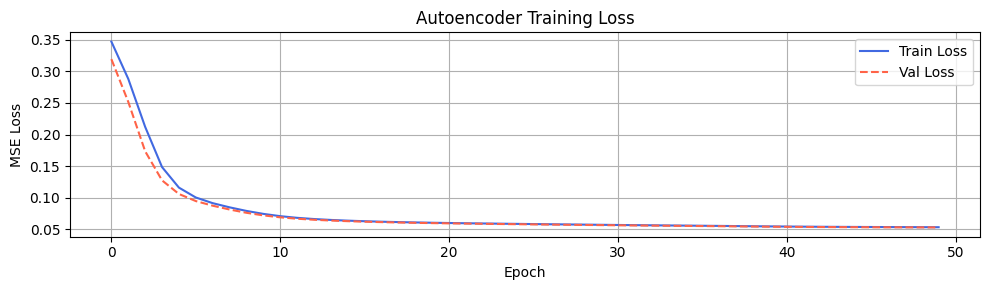

2026-03-07 09:39:01,505 [INFO] Threshold (mean + 1*std): 0.109040


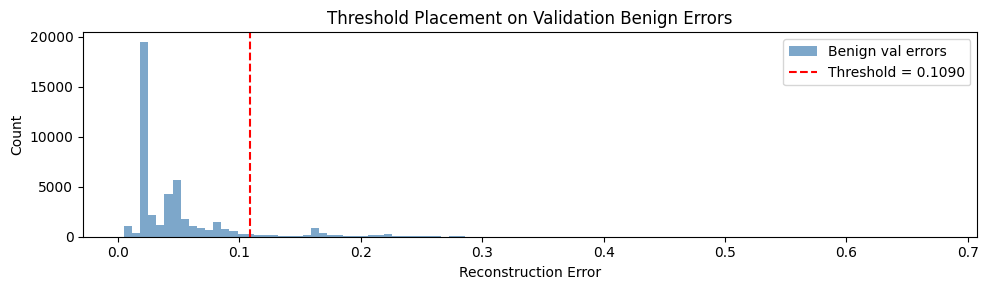

2026-03-07 09:39:01,969 [WARNING] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2026-03-07 09:39:01,998 [INFO] Saved: autoencoder_model.h5
2026-03-07 09:39:01,999 [INFO] Saved: threshold.pkl


In [8]:
# ---Build and train autoencoder---
#
# Architecture :
#   encoder: Dense(encoding_dim, relu)
#   decoder: Dense(input_dim, sigmoid)
#
# sigmoid output is correct here — input is MinMax scaled to [0,1]
# output space must also be [0,1] for MSE loss to be meaningful.
#
# Threshold = mean + 2*std of validation reconstruction errors

def build_autoencoder(input_dim):
    encoding_dim = max(int(input_dim * AE['encoding_ratio']), 8)

    input_layer = Input(shape=(input_dim,))
    encoder     = Dense(encoding_dim, activation='relu')(input_layer)
    decoder     = Dense(input_dim,    activation='sigmoid')(encoder)

    ae = Model(inputs=input_layer, outputs=decoder, name='Autoencoder')
    ae.compile(optimizer=Adam(AE['learning_rate']), loss='mean_squared_error')
    return ae


def train_autoencoder(benign_pca):
    log.info('Training autoencoder on benign traffic only …')
    X_train, X_test = train_test_split(
        benign_pca, test_size=0.2, random_state=D['seed'])

    ae = build_autoencoder(X_train.shape[1])
    ae.summary(print_fn=log.info)

    history = ae.fit(
        X_train, X_train,
        epochs=AE['epochs'],
        batch_size=AE['batch_size'],
        shuffle=True,
        validation_data=(X_test, X_test),
        callbacks=[
            EarlyStopping(patience=AE['patience_early_stop'],
                          restore_best_weights=True, verbose=1)
        ],
        verbose=1,
    )

    # Training loss curve
    plt.figure(figsize=(10, 3))
    plt.plot(history.history['loss'],     label='Train Loss', color='royalblue')
    plt.plot(history.history['val_loss'], label='Val Loss',   color='tomato',
             linestyle='--')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.title('Autoencoder Training Loss')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(ARTIFACTS + 'ae_training_curve.png', dpi=100)
    plt.show()

    # Threshold: mean + 2*std 
    recon_errors = np.mean(
        np.power(X_test - ae.predict(X_test, verbose=0), 2), axis=1)
    threshold = float(
        np.mean(recon_errors) + AE['threshold_sigma'] * np.std(recon_errors))
    log.info(f'Threshold (mean + {AE["threshold_sigma"]}*std): {threshold:.6f}')

    # Threshold verification: confirm it sits above benign errors 
    plt.figure(figsize=(10, 3))
    plt.hist(recon_errors, bins=100, alpha=0.7,
             color='steelblue', label='Benign val errors')
    plt.axvline(threshold, color='red', linestyle='--',
                label=f'Threshold = {threshold:.4f}')
    plt.xlabel('Reconstruction Error'); plt.ylabel('Count')
    plt.title('Threshold Placement on Validation Benign Errors')
    plt.legend(); plt.tight_layout()
    plt.savefig(ARTIFACTS + 'ae_threshold_verification.png', dpi=100)
    plt.show()

    _save(ae,        'autoencoder_model.h5')
    _save(threshold, 'threshold.pkl')
    return ae, threshold


if TRAIN:
    ae, threshold = train_autoencoder(data['benign_pca'])
else:
    log.info('Loading pre-trained autoencoder …')
    ae        = _load('autoencoder_model.h5')
    threshold = float(_load('threshold.pkl'))
    log.info(f'Autoencoder loaded. Threshold = {threshold:.6f} ✅')

## Random Forest Training (Phase 2)

In [9]:
# ---Train Random Forest---
# Trained on attack samples only.
# class_weight=balanced handles residual imbalance.
# max_depth=15 caps RAM and prediction latency.

def train_rf(attack_pca, attack_labels):
    log.info(f'Training RF on {len(attack_pca):,} attack samples …')
    le = LabelEncoder()
    y  = le.fit_transform(attack_labels)
    log.info(f'Attack classes: {list(le.classes_)}')

    rf = RandomForestClassifier(
        n_estimators = RF['n_estimators'],
        max_depth    = RF['max_depth'],
        n_jobs       = RF['n_jobs'],
        class_weight = RF['class_weight'],
        random_state = D['seed'],
        verbose      = 1,
    )
    rf.fit(attack_pca, y)
    _save(rf, 'rf_classifier.pkl')
    _save(le, 'label_encoder.pkl')
    log.info('RF training complete ')
    return rf, le


if TRAIN:
    rf, le = train_rf(data['attack_pca'], data['attack_labels'])
else:
    log.info('Loading pre-trained RF …')
    rf = _load('rf_classifier.pkl', mmap=True)  # memory-map: no full RAM copy
    le = _load('label_encoder.pkl')
    log.info('RF loaded ')

2026-03-07 09:39:02,096 [INFO] Training RF on 2,341,240 attack samples …
2026-03-07 09:39:02,445 [INFO] Attack classes: ['Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 10.2min finished
2026-03-07 09:49:20,101 [INFO] Saved: rf_classifier.pkl
2026-03-07 09:49:20,103 [INFO] Saved: label_encoder.pkl
2026-03-07 09:49:20,104 [INFO] RF training complete 


In [10]:
# ---Load artifacts and preprocess test set---
# when TRAIN=True models already in memory from data dict
# when TRAIN=False load everything from /kaggle/working/

if TRAIN:
    scaler           = data['scaler']
    pca_ae           = data['pca_ae']
    pca_rf           = data['pca_rf']
    training_columns = data['columns']
    test_df          = _load('hold_out_test_set.pkl')
else:
    scaler           = _load('scaler.pkl')
    pca_ae           = _load('pca_ae.pkl')
    pca_rf           = _load('pca_rf.pkl')
    training_columns = _load('training_columns.pkl')
    test_df          = _load('hold_out_test_set.pkl')
    log.info(f'training_columns loaded: {len(training_columns)} columns')

if EVALUATE:
    true_labels = test_df['Label']
    features    = test_df.drop(columns=['Label'])

    features_encoded    = pd.get_dummies(
        features, columns=D['cat_cols'], drop_first=True)
    features_harmonized = features_encoded.reindex(
        columns=training_columns, fill_value=0)
    features_scaled     = scaler.transform(
        features_harmonized.values.astype('float32'))

    # Transform into each model's own PCA space
    features_pca_ae = pca_ae.transform(features_scaled).astype('float32')
    features_pca_rf = pca_rf.transform(features_scaled).astype('float32')

    log.info(f'Test AE space: {features_pca_ae.shape}')
    log.info(f'Test RF space: {features_pca_rf.shape}')

2026-03-07 09:49:25,743 [INFO] Test AE space: (565569, 11)
2026-03-07 09:49:25,744 [INFO] Test RF space: (565569, 14)


In [11]:
#save artifacts
if TRAIN:
    import shutil, os
    output_dir = '/kaggle/working/artifacts_backup/'
    os.makedirs(output_dir, exist_ok=True)

    artifacts_to_save = [
        'autoencoder_model.h5',
        'rf_classifier.pkl',
        'label_encoder.pkl',
        'scaler.pkl',
        'pca_ae.pkl',
        'pca_rf.pkl',
        'training_columns.pkl',
        'threshold.pkl',
        'hold_out_test_set.pkl',
        'config.yaml',
        'ids_run.log',
    ]

    print('Copying artifacts:')
    for f in artifacts_to_save:
        src = f'/kaggle/working/{f}'
        dst = f'{output_dir}{f}'
        if os.path.exists(src):
            shutil.copy2(src, dst)
            size = os.path.getsize(dst) / 1e6
            print(f'  {f:<45s}  {size:.2f} MB')
        else:
            print(f'  MISSING: {f}')

    print('\nAll artifacts copied. Now commit the notebook.')
    print('After commit: Output tab → New Dataset → cicids-artifacts')
else:
    print('TRAIN=False — backup skipped, loading from saved dataset')

Copying artifacts:
  autoencoder_model.h5                           0.02 MB
  rf_classifier.pkl                              63.49 MB
  label_encoder.pkl                              0.00 MB
  scaler.pkl                                     0.00 MB
  pca_ae.pkl                                     0.00 MB
  pca_rf.pkl                                     0.01 MB
  training_columns.pkl                           0.00 MB
  threshold.pkl                                  0.00 MB
  hold_out_test_set.pkl                          69.28 MB
  config.yaml                                    0.00 MB
  ids_run.log                                    0.00 MB

All artifacts copied. Now commit the notebook.
After commit: Output tab → New Dataset → cicids-artifacts


In [12]:
# ---Two-phase vectorised inference---
# Phase 1 runs in AE's PCA space (pca_ae)
# Phase 2 runs in RF's PCA space (pca_rf)
# Each model sees the feature space it was trained on.

if EVALUATE:
    log.info('Running two-phase inference …')
    t0 = time.time()

    # ---Phase 1: AE anomaly detection in pca_ae space---
    reconstructions = ae.predict(
        features_pca_ae, batch_size=AE['batch_size'] * 2, verbose=1)
    errors       = np.mean(
        np.power(features_pca_ae - reconstructions, 2), axis=1)
    phase1_flags = errors > threshold

    # ---Phase 2: RF classification in pca_rf space---
    final_predictions = np.where(
        phase1_flags, 'ATTACK_PENDING', 'BENIGN').astype(object)
    attack_indices = np.where(phase1_flags)[0]

    if len(attack_indices):
        attack_preds_encoded              = rf.predict(
            features_pca_rf[attack_indices])    # 
        attack_labels_pred                = le.inverse_transform(
            attack_preds_encoded)
        final_predictions[attack_indices] = attack_labels_pred

    elapsed = time.time() - t0
    log.info(f'Inference: {len(features_pca_ae):,} samples in {elapsed:.2f}s')
    log.info(f'Flagged:   {phase1_flags.sum():,} / {len(phase1_flags):,}')

2026-03-07 09:49:25,984 [INFO] Running two-phase inference …


139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.4s finished
2026-03-07 09:49:27,970 [INFO] Inference: 565,569 samples in 1.98s
2026-03-07 09:49:27,971 [INFO] Flagged:   91,748 / 565,569


       Phase 1: Anomaly Detection Report
              precision    recall  f1-score   support

      ATTACK       0.54      0.44      0.48    111311
      BENIGN       0.87      0.91      0.89    454258

    accuracy                           0.81    565569
   macro avg       0.70      0.67      0.69    565569
weighted avg       0.80      0.81      0.81    565569



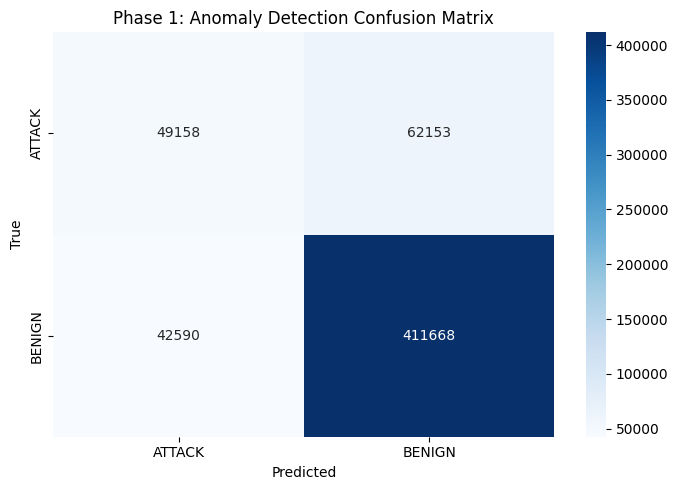

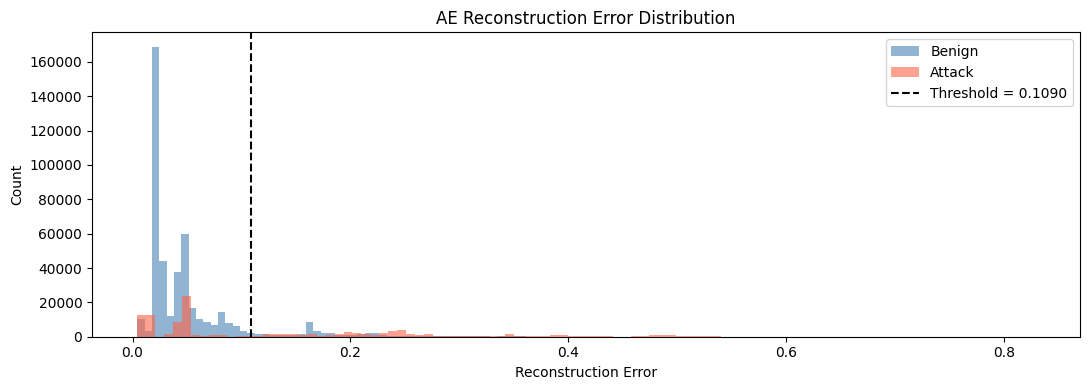

2026-03-07 09:49:34,366 [INFO] Phase 1  Precision=0.5358  Recall=0.4416  F1=0.4842


In [13]:
# ---Phase 1 report + confusion matrix + error distribution---

if EVALUATE:
    true_binary = np.where(true_labels == 'BENIGN', 'BENIGN', 'ATTACK')
    pred_binary = np.where(final_predictions == 'BENIGN', 'BENIGN', 'ATTACK')

    p1_prec = precision_score(true_binary, pred_binary, pos_label='ATTACK', zero_division=0)
    p1_rec  = recall_score(true_binary, pred_binary,    pos_label='ATTACK', zero_division=0)
    p1_f1   = f1_score(true_binary, pred_binary,        pos_label='ATTACK', zero_division=0)

    print('=' * 55)
    print('       Phase 1: Anomaly Detection Report')
    print('=' * 55)
    print(classification_report(true_binary, pred_binary))

    # Confusion matrix
    cm = confusion_matrix(true_binary, pred_binary, labels=['ATTACK', 'BENIGN'])
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ATTACK', 'BENIGN'], yticklabels=['ATTACK', 'BENIGN'])
    plt.title('Phase 1: Anomaly Detection Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(ARTIFACTS + 'phase1_confusion_matrix.png', dpi=100)
    plt.show()

    # Reconstruction error distribution - key diagnostic for threshold
    plt.figure(figsize=(11, 4))
    plt.hist(errors[true_binary == 'BENIGN'], bins=100, alpha=0.6, color='steelblue', label='Benign')
    plt.hist(errors[true_binary == 'ATTACK'], bins=100, alpha=0.6, color='tomato',    label='Attack')
    plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.4f}')
    plt.xlabel('Reconstruction Error'); plt.ylabel('Count')
    plt.title('AE Reconstruction Error Distribution')
    plt.legend(); plt.tight_layout()
    plt.savefig(ARTIFACTS + 'ae_error_distribution.png', dpi=100)
    plt.show()

    log.info(f'Phase 1  Precision={p1_prec:.4f}  Recall={p1_rec:.4f}  F1={p1_f1:.4f}')

2026-03-07 09:49:34,503 [INFO] Phase 2 Accuracy on detected attacks: 98.60%


  Phase 2: Attack Classification Report
  (on correctly detected attacks only)
                  precision    recall  f1-score   support

             Bot       1.00      1.00      1.00         7
            DDoS       1.00      0.98      0.99     15990
   DoS GoldenEye       0.84      1.00      0.91      1205
        DoS Hulk       0.99      0.99      0.99     30959
DoS Slowhttptest       0.99      0.97      0.98       311
   DoS slowloris       0.98      1.00      0.99       639
      Heartbleed       1.00      1.00      1.00         2
    Infiltration       1.00      1.00      1.00         5
        PortScan       1.00      0.50      0.67        38
     SSH-Patator       0.00      0.00      0.00         1
Web Attack - XSS       1.00      1.00      1.00         1

        accuracy                           0.99     49158
       macro avg       0.89      0.86      0.87     49158
    weighted avg       0.99      0.99      0.99     49158



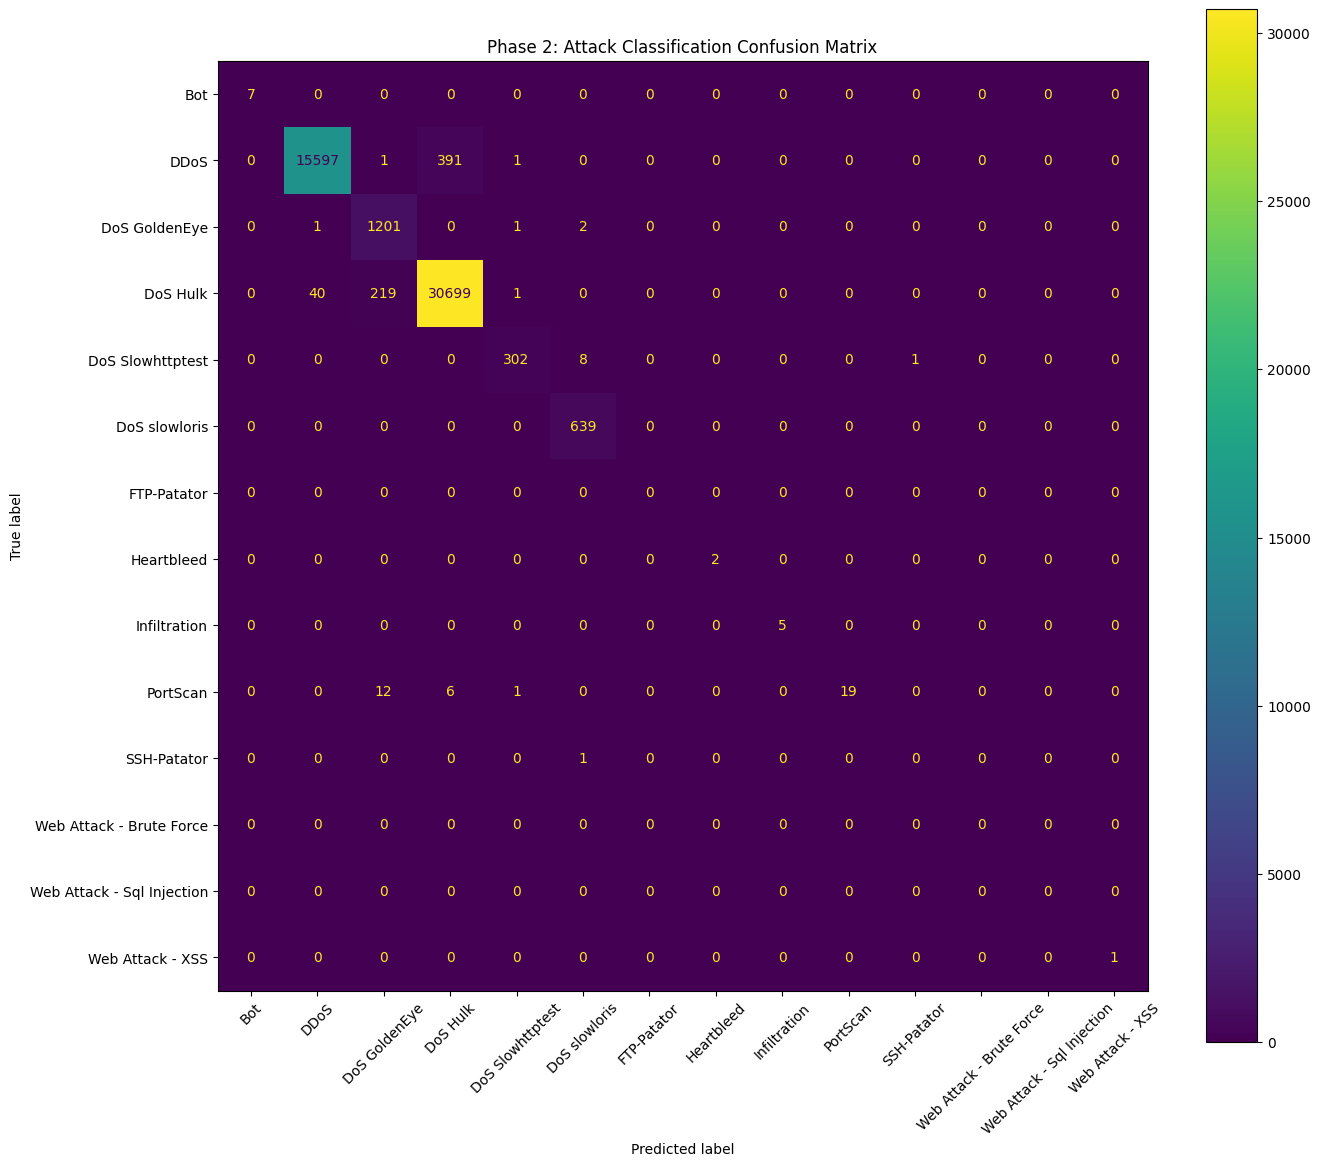

  End-to-End Pipeline Report (all samples)


2026-03-07 09:49:39,850 [INFO] End-to-End Macro F1: 0.2622


                            precision    recall  f1-score   support

                    BENIGN       0.87      0.91      0.89    454258
                       Bot       0.88      0.02      0.04       391
                      DDoS       0.96      0.61      0.75     25605
             DoS GoldenEye       0.06      0.58      0.10      2059
                  DoS Hulk       0.99      0.67      0.80     46025
          DoS Slowhttptest       0.04      0.27      0.07      1100
             DoS slowloris       0.17      0.55      0.26      1159
               FTP-Patator       0.00      0.00      0.00      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.01      0.71      0.02         7
                  PortScan       1.00      0.00      0.00     31761
               SSH-Patator       0.00      0.00      0.00      1180
  Web Attack - Brute Force       0.00      0.00      0.00       301
Web Attack - Sql Injection       0.00      0.00

In [14]:
# ---Phase 2 — Attack Classification Report---

if EVALUATE:
    final_series = pd.Series(final_predictions, index=true_labels.index)
    attack_mask  = (true_binary == 'ATTACK') & (pred_binary == 'ATTACK')

    print('=' * 55)
    print('  Phase 2: Attack Classification Report')
    print('  (on correctly detected attacks only)')
    print('=' * 55)

    if attack_mask.sum():
        p2_acc = accuracy_score(
            true_labels[attack_mask], final_series[attack_mask])
        log.info(f'Phase 2 Accuracy on detected attacks: {p2_acc:.2%}')
        print(classification_report(
            true_labels[attack_mask], final_series[attack_mask]))

        # ── Phase 2 multiclass confusion matrix ───────────────────────────
        cm2 = confusion_matrix(
            true_labels[attack_mask],
            final_series[attack_mask],
            labels=list(le.classes_))
        fig, ax = plt.subplots(figsize=(14, 12))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm2, display_labels=le.classes_)
        disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
        plt.title('Phase 2: Attack Classification Confusion Matrix')
        plt.tight_layout()
        plt.savefig(ARTIFACTS + 'phase2_confusion_matrix.png', dpi=100)
        plt.show()
    else:
        log.warning('No attacks correctly detected — Phase 2 report skipped.')

    # End-to-end: all samples
    print('=' * 55)
    print('  End-to-End Pipeline Report (all samples)')
    print('=' * 55)
    e2e_f1 = f1_score(
        true_labels, final_predictions, average='macro', zero_division=0)
    log.info(f'End-to-End Macro F1: {e2e_f1:.4f}')
    print(classification_report(true_labels, final_predictions))

In [15]:
# ---Log all metrics to MLflow---
# Creates a local mlruns/ folder in /kaggle/working/

if EVALUATE:
    mlflow.set_tracking_uri(f'file://{ARTIFACTS}mlruns')
    mlflow.set_experiment('IDS_CICIDS_Pipeline')

    with mlflow.start_run(run_name='evaluation'):
        mlflow.log_params({
            'ae_threshold_sigma': AE['threshold_sigma'],   
            'rf_max_depth':       RF['max_depth'],
            'rf_n_estimators':    RF['n_estimators'],
            'pca_ae_variance':    cfg['pca']['variance_ae'],  
            'pca_rf_variance':    cfg['pca']['variance_rf'],  
        })
        mlflow.log_metrics({
            'phase1_precision':    p1_prec,
            'phase1_recall':       p1_rec,
            'phase1_f1':           p1_f1,
            'phase2_accuracy':     p2_acc if attack_mask.sum() else 0.0,
            'end_to_end_macro_f1': e2e_f1,
            'ae_threshold':        float(threshold),
            'n_test_samples':      len(true_labels),
            'n_flagged_as_attack': int(phase1_flags.sum()),
        })
        for artifact in [
            'phase1_confusion_matrix.png',
            'phase2_confusion_matrix.png',
            'ae_error_distribution.png',
            'ae_threshold_verification.png',
            'ae_training_curve.png'
        ]:
            path = ARTIFACTS + artifact
            if os.path.exists(path):
                mlflow.log_artifact(path)

    print(' Metrics logged to MLflow')
    print(f'   Location: {ARTIFACTS}mlruns/')

2026/03/07 09:49:47 INFO mlflow.tracking.fluent: Experiment with name 'IDS_CICIDS_Pipeline' does not exist. Creating a new experiment.


 Metrics logged to MLflow
   Location: /kaggle/working/mlruns/


  LIVE THREAT DETECTION LOG

  🚨 THREAT ALERT — Chunk 5646
  Total flagged : 23 packets
  Attack Type                      Severity        Packets
  -------------------------------- -------------- --------
  DoS GoldenEye                    🔴 CRITICAL           21
  DoS Slowhttptest                 🔴 CRITICAL            2

  🚨 THREAT ALERT — Chunk 5647
  Total flagged : 24 packets
  Attack Type                      Severity        Packets
  -------------------------------- -------------- --------
  DoS GoldenEye                    🔴 CRITICAL           15
  DoS Slowhttptest                 🔴 CRITICAL            4
  SSH-Patator                      🟠 HIGH                3
  DoS slowloris                    🔴 CRITICAL            1
  DDoS                             🔴 CRITICAL            1

  🚨 THREAT ALERT — Chunk 5648
  Total flagged : 20 packets
  Attack Type                      Severity        Packets
  -------------------------------- -------------- --------
  DoS GoldenEye          

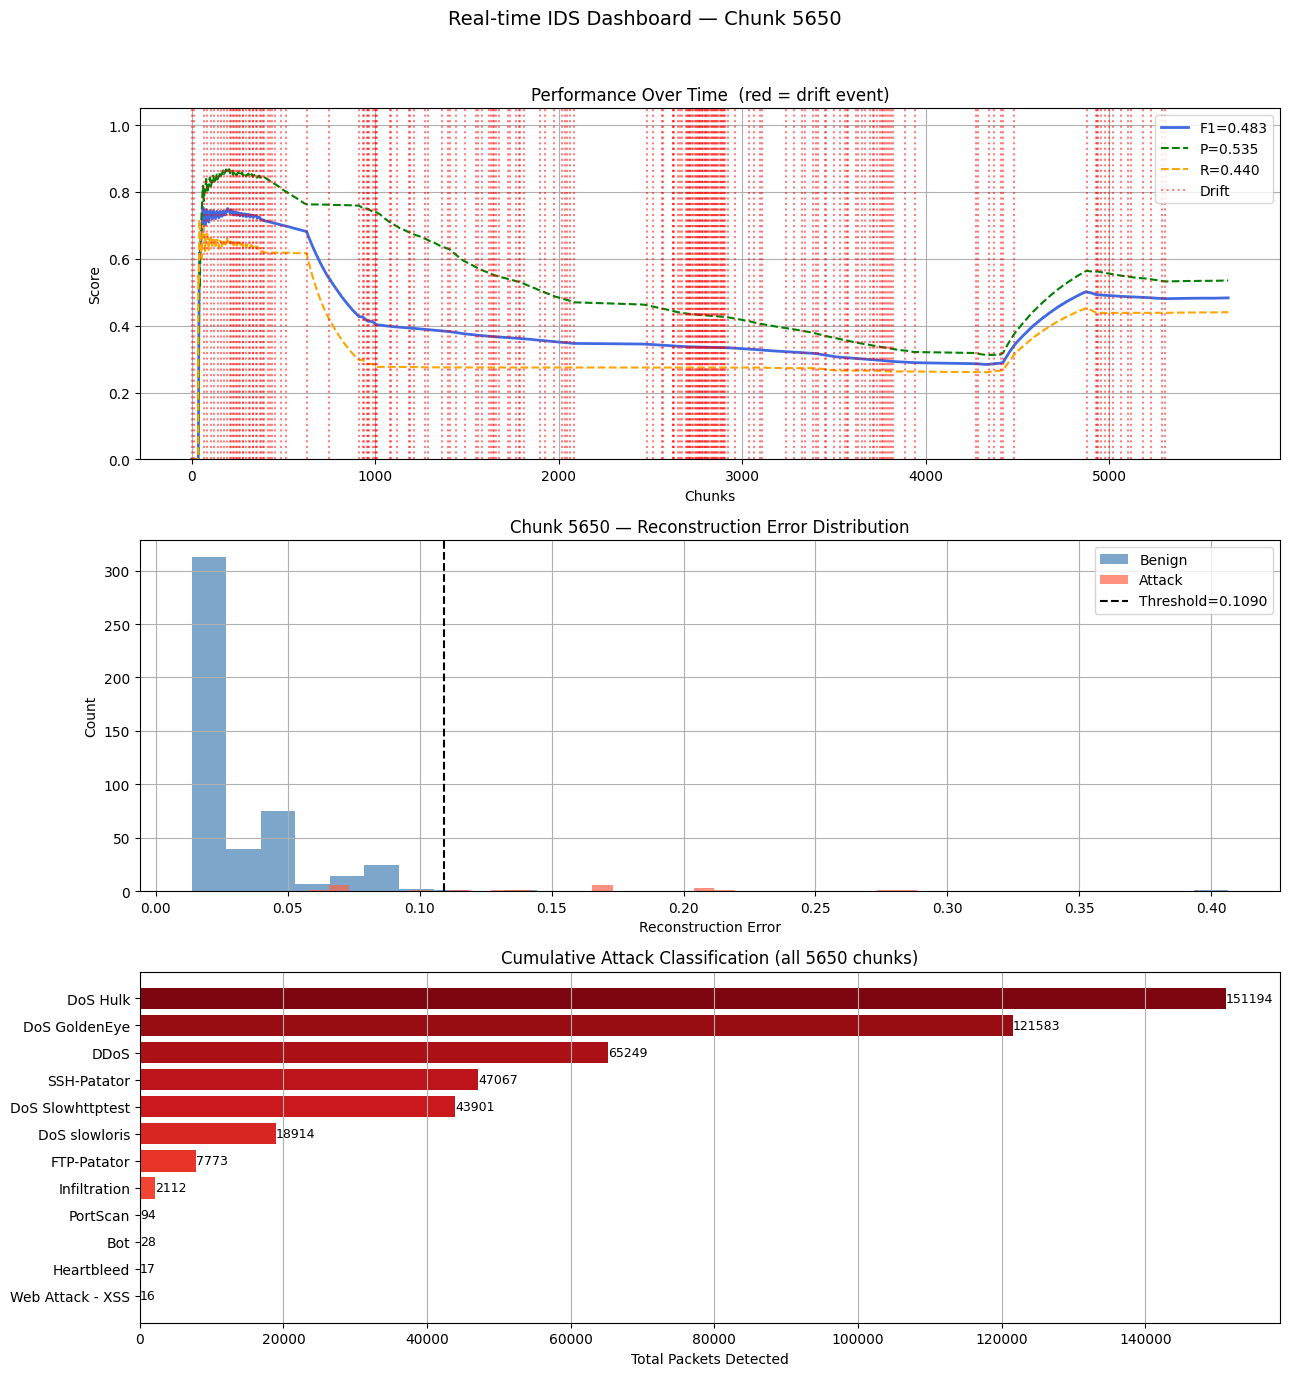

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_job


  FINAL THREAT DETECTION SUMMARY
  Chunks processed       : 5656
  Packets scanned        : 2,828,000
  Confirmed attacks (TP) : 245,114
  False alarms   (FP)    : 212,963
  Missed attacks (FN)    : 311,442
  Precision              : 53.51%
  Recall                 : 44.04%
  F1 Score               : 48.32%

  Attack types detected:
    DoS Hulk                         🔴 CRITICAL      151,194
    DoS GoldenEye                    🔴 CRITICAL      121,687
    DDoS                             🔴 CRITICAL       65,250
    SSH-Patator                      🟠 HIGH           47,082
    DoS Slowhttptest                 🔴 CRITICAL       43,909
    DoS slowloris                    🔴 CRITICAL       18,914
    FTP-Patator                      🟠 HIGH            7,773
    Infiltration                     🔴 CRITICAL        2,113
    PortScan                         🟠 HIGH               94
    Bot                              🟠 HIGH               28
    Heartbleed                       🔴 CRITICAL       

In [16]:
# ---Stream detection with ADWIN drift monitoring---
# Each chunk preprocessed into two PCA spaces:
#   X_ae → AE reconstruction (Phase 1)
#   X_rf → RF classification (Phase 2, flagged rows only)

if STREAM:
    if 'scaler' not in dir():
        scaler = _load('scaler.pkl')
    if 'pca_ae' not in dir():
        pca_ae = _load('pca_ae.pkl')
    if 'pca_rf' not in dir():
        pca_rf = _load('pca_rf.pkl')
    if 'training_columns' not in dir():
        training_columns = _load('training_columns.pkl')
    log.info(f'training_columns verified: {len(training_columns)} columns')

    adwin        = river_drift.ADWIN(delta=DR['delta'])
    drift_events = []

    tp = fp = fn = tn = 0
    correct_classifications = total_attacks_classified = 0
    history = {'f1': [], 'precision': [], 'recall': []}

    # ---Accumulate all alerts here — survives clear_output---
    alert_log = []

    # ---Cumulative attack counter across all chunks---
    cumulative_attacks = {}

    chunk_size  = ST['chunk_size']
    dash_freq   = ST['dashboard_freq']
    infer_batch = ST['infer_batch']
    chunk_idx   = 0

    severity = {
        'DDoS':                       '🔴 CRITICAL',
        'DoS Hulk':                   '🔴 CRITICAL',
        'DoS GoldenEye':              '🔴 CRITICAL',
        'DoS slowloris':              '🔴 CRITICAL',
        'DoS Slowhttptest':           '🔴 CRITICAL',
        'Infiltration':               '🔴 CRITICAL',
        'Heartbleed':                 '🔴 CRITICAL',
        'PortScan':                   '🟠 HIGH',
        'FTP-Patator':                '🟠 HIGH',
        'SSH-Patator':                '🟠 HIGH',
        'Bot':                        '🟠 HIGH',
        'Web Attack - Brute Force':   '🟡 MEDIUM',
        'Web Attack - XSS':           '🟡 MEDIUM',
        'Web Attack - Sql Injection': '🟡 MEDIUM',
    }

    log.info(f'Stream started — chunk_size={chunk_size}  infer_batch={infer_batch}')

    for raw_chunk in pd.read_csv(
            INPUT_PATH + D['original'],
            chunksize=chunk_size, low_memory=False):

        raw_chunk.columns = raw_chunk.columns.str.strip()

        if 'Destination_port_group' in raw_chunk.columns:
            raw_chunk['Destination_port_group'] = (
                raw_chunk['Destination_port_group']
                .str.strip().str.lower()
                .str.replace(' ', '_', regex=False)
                .str.replace('-', '_', regex=False)
            )

        if 'Label' not in raw_chunk.columns or raw_chunk.empty:
            chunk_idx += 1
            continue

        chunk_idx += 1

        true_labels_c = raw_chunk['Label'].values
        features_c    = raw_chunk.drop(columns=['Label'])

        try:
            features_c = features_c.copy()
            features_c.replace([np.inf, -np.inf], np.nan, inplace=True)
            features_c.fillna(0, inplace=True)
            enc    = pd.get_dummies(
                features_c, columns=D['cat_cols'], drop_first=True)
            harm   = enc.reindex(columns=training_columns, fill_value=0)
            scaled = scaler.transform(harm.values.astype('float32'))
            X_ae   = pca_ae.transform(scaled).astype('float32')
            X_rf   = pca_rf.transform(scaled).astype('float32')
        except Exception as e:
            log.warning(f'Chunk {chunk_idx} preprocess failed: {e}')
            continue

        # Phase 1----
        recon    = ae.predict(X_ae, batch_size=infer_batch, verbose=0)
        errors_c = np.mean(np.power(X_ae - recon, 2), axis=1)
        flags_c  = errors_c > threshold

        # Phase 2---
        pred_labels_c = np.full(len(X_ae), 'BENIGN', dtype=object)
        atk_idx = np.where(flags_c)[0]

        if len(atk_idx):
            atk_preds = rf.predict(X_rf[atk_idx])
            pred_labels_c[atk_idx] = le.inverse_transform(atk_preds)

            attack_counts = pd.Series(
                pred_labels_c[atk_idx]).value_counts()

            # Update cumulative counter
            for attack_type, count in attack_counts.items():
                cumulative_attacks[attack_type] = (
                    cumulative_attacks.get(attack_type, 0) + count)

            # Build alert string — stored so it survives clear_output
            lines = []
            lines.append(f'\n{"="*58}')
            lines.append(f'  🚨 THREAT ALERT — Chunk {chunk_idx}')
            lines.append(f'{"="*58}')
            lines.append(f'  Total flagged : {len(atk_idx)} packets')
            lines.append(
                f'  {"Attack Type":<32s} {"Severity":<14s} {"Packets":>8s}')
            lines.append(
                f'  {"-"*32} {"-"*14} {"-"*8}')
            for attack_type, count in attack_counts.items():
                sev = severity.get(attack_type, '🟡 MEDIUM')
                lines.append(
                    f'  {attack_type:<32s} {sev:<14s} {count:>8,}')
            alert_log.append('\n'.join(lines))

        # ---Metrics---
        true_bin_c = (true_labels_c != 'BENIGN')
        pred_bin_c = (pred_labels_c != 'BENIGN')

        tp += int(( true_bin_c &  pred_bin_c).sum())
        fp += int((~true_bin_c &  pred_bin_c).sum())
        fn += int(( true_bin_c & ~pred_bin_c).sum())
        tn += int((~true_bin_c & ~pred_bin_c).sum())

        tp_mask = true_bin_c & pred_bin_c
        if tp_mask.sum():
            total_attacks_classified += int(tp_mask.sum())
            correct_classifications  += int(
                (pred_labels_c[tp_mask] == true_labels_c[tp_mask]).sum())

        # ---ADWIN---
        for err in errors_c[~pred_bin_c]:
            adwin.update(float(err))
            if adwin.drift_detected:
                msg = f'⚠️  Concept drift at chunk {chunk_idx}!'
                log.warning(msg)
                drift_events.append(chunk_idx)
                alert_log.append(msg)

        # ---Rolling metrics---
        prec = tp/(tp+fp) if (tp+fp) else 0
        rec  = tp/(tp+fn) if (tp+fn) else 0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0
        history['f1'].append(f1)
        history['precision'].append(prec)
        history['recall'].append(rec)

        # ---Dashboard---
        if chunk_idx % dash_freq == 0 and chunk_idx > 0:
            clear_output(wait=True)

            print(f'{"="*58}')
            print(f'  LIVE THREAT DETECTION LOG')
            print(f'{"="*58}')
            if alert_log:
                for alert in alert_log[-5:]:
                    print(alert)
                if len(alert_log) > 5:
                    print(f'\n  ... and {len(alert_log)-5} earlier alerts'
                          f' (see ids_run.log for full history)')
            else:
                print('  No threats detected yet')

            # ── Live metrics summary line ──────────────────────────────────
            print(f'\n  Chunk {chunk_idx} | '
                  f'F1={f1:.3f} | P={prec:.3f} | R={rec:.3f} | '
                  f'TP={tp} FP={fp} FN={fn}')
            if drift_events:
                print(f'  ⚠️  Drift at chunks: {drift_events}')
            print()

            # ---Plots---
            fig, axs = plt.subplots(3, 1, figsize=(13, 14))
            fig.suptitle(
                f'Real-time IDS Dashboard — Chunk {chunk_idx}', fontsize=14)

            # Panel 1: Performance over time
            axs[0].plot(history['f1'],        color='royalblue',
                        linewidth=2,    label=f'F1={f1:.3f}')
            axs[0].plot(history['precision'], color='green',
                        linestyle='--', label=f'P={prec:.3f}')
            axs[0].plot(history['recall'],    color='orange',
                        linestyle='--', label=f'R={rec:.3f}')
            for de in drift_events:
                axs[0].axvline(de, color='red', alpha=0.5, linestyle=':',
                               label='Drift' if de == drift_events[0] else '')
            axs[0].set_ylim(0, 1.05)
            axs[0].legend(); axs[0].grid(True)
            axs[0].set_title('Performance Over Time  (red = drift event)')
            axs[0].set_xlabel('Chunks'); axs[0].set_ylabel('Score')

            # Panel 2: Reconstruction error distribution
            b_err = errors_c[~true_bin_c]
            a_err = errors_c[ true_bin_c]
            if len(b_err):
                axs[1].hist(b_err, bins=30, alpha=0.7,
                            color='steelblue', label='Benign')
            if len(a_err):
                axs[1].hist(a_err, bins=30, alpha=0.7,
                            color='tomato', label='Attack')
            axs[1].axvline(threshold, color='black', linestyle='--',
                           label=f'Threshold={threshold:.4f}')
            axs[1].set_title(
                f'Chunk {chunk_idx} — Reconstruction Error Distribution')
            axs[1].set_xlabel('Reconstruction Error')
            axs[1].set_ylabel('Count')
            axs[1].legend(); axs[1].grid(True)

            # Panel 3: Cumulative attack classification across all chunks
            if cumulative_attacks:
                cum_series = pd.Series(cumulative_attacks).sort_values(
                    ascending=True)
                colors = plt.cm.Reds(
                    [0.4 + 0.6 * i/len(cum_series)
                     for i in range(len(cum_series))])
                axs[2].barh(cum_series.index, cum_series.values,
                            color=colors)
                for i, val in enumerate(cum_series.values):
                    axs[2].text(val + 0.5, i, str(val),
                                va='center', fontsize=9)
                axs[2].set_xlabel('Total Packets Detected')
                axs[2].set_title(
                    f'Cumulative Attack Classification'
                    f' (all {chunk_idx} chunks)')
                axs[2].grid(True, axis='x')
            else:
                axs[2].text(0.5, 0.5, 'No attacks detected yet',
                            ha='center', va='center',
                            transform=axs[2].transAxes,
                            fontsize=12, color='grey')
                axs[2].set_title('Cumulative Attack Type Classification')

            fig.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()
            plt.close(fig)

    # ---Final summary---
    print(f'\n{"="*58}')
    print(f'  FINAL THREAT DETECTION SUMMARY')
    print(f'{"="*58}')
    print(f'  Chunks processed       : {chunk_idx}')
    print(f'  Packets scanned        : {chunk_idx * chunk_size:,}')
    print(f'  Confirmed attacks (TP) : {tp:,}')
    print(f'  False alarms   (FP)    : {fp:,}')
    print(f'  Missed attacks (FN)    : {fn:,}')
    print(f'  Precision              : {prec:.2%}')
    print(f'  Recall                 : {rec:.2%}')
    print(f'  F1 Score               : {f1:.2%}')
    if cumulative_attacks:
        print(f'\n  Attack types detected:')
        for atk, cnt in sorted(
                cumulative_attacks.items(), key=lambda x: -x[1]):
            sev = severity.get(atk, '🟡 MEDIUM')
            print(f'    {atk:<32s} {sev:<14s} {cnt:>8,}')
    if drift_events:
        print(f'\n  ⚠️  Drift at chunks: {drift_events}')
        print(f'  Recommendation: Retrain autoencoder on recent traffic')
    else:
        print(f'\n  No concept drift detected')
    print(f'{"="*58}')

    log.info('Stream complete')
    log.info(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
    log.info(f'Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    if total_attacks_classified:
        log.info(
            f'Phase 2 Accuracy: '
            f'{correct_classifications/total_attacks_classified:.2%} '
            f'({correct_classifications}/{total_attacks_classified})')

# Real-time Stream Detection and Concept-drift

In [17]:
# ---Final artifact listing---

print('Final /kaggle/working/ contents:')
print('-' * 55)
total_mb = 0
for f in sorted(os.listdir('/kaggle/working/')):
    size_mb = os.path.getsize(f'/kaggle/working/{f}') / 1e6
    total_mb += size_mb
    print(f'  {f:45s} {size_mb:6.2f} MB')
print('-' * 55)
print(f'  Total                                          {total_mb:6.2f} MB')
print()

Final /kaggle/working/ contents:
-------------------------------------------------------
  __notebook__.ipynb                              0.79 MB
  ae_error_distribution.png                       0.03 MB
  ae_threshold_verification.png                   0.02 MB
  ae_training_curve.png                           0.03 MB
  artifacts_backup                                0.00 MB
  autoencoder_model.h5                            0.02 MB
  config.yaml                                     0.00 MB
  hold_out_test_set.pkl                          69.28 MB
  ids_run.log                                     0.02 MB
  label_encoder.pkl                               0.00 MB
  mlruns                                          0.00 MB
  pca_ae.pkl                                      0.00 MB
  pca_rf.pkl                                      0.01 MB
  phase1_confusion_matrix.png                     0.03 MB
  phase2_confusion_matrix.png                     0.12 MB
  rf_classifier.pkl                      